# Performance Comparison of Datasets19–25

This notebook evaluates how progressive feature engineering affects LTE and 5G NR signal-quality classification.

Datasets19–25 are compared using Random Forest, LightGBM, and XGBoost under identical stratified five-fold cross-validation. Macro-F1 is used as the primary metric because the target classes are imbalanced.

The comparison determines whether progressively adding environmental, infrastructure, interaction, remote-sensing, and geographic predictors improves classification performance.

### ※ Related dissertation sections

- Section 3.1 (Research Approach—Modelling and Evaluation)
- Section 4.2 (Effect of Progressive Feature Engineering on Classification Performance)
- Tables 4.2–4.4

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Environment and Reproducibility Settings

The required machine-learning libraries are installed and imported.

A fixed random state of 42 and five cross-validation folds are used to improve reproducibility and ensure consistent comparisons across datasets and models.

### ※ Related dissertation sections

- Section 3.1 (Research Approach—Modelling and Evaluation)
- Appendix C, Table C.1 (Reproducibility Summary)

In [2]:
# ============================================================
# Cell 1. Install and Import Libraries
# ============================================================

!pip install -q lightgbm xgboost

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Reproducibility settings
RANDOM_STATE = 42
N_SPLITS = 5

print("Pandas version   :", pd.__version__)
print("NumPy version    :", np.__version__)

Pandas version   : 2.2.3
NumPy version    : 2.1.3


## 2. Dataset Inputs and Progressive Predictor Sets

Datasets19–25 are loaded from their respective output locations.

The number of predictors increases progressively from 11 in Dataset19 to 35 in Dataset25. File availability, labelled-grid counts, target labels, and predictor counts are validated before model evaluation.

### ※ Related dissertation sections

- Section 4.1.3 (Progressive Feature Engineering)
- Section 4.2 (Effect of Progressive Feature Engineering on Classification Performance)
- Table 4.2 (Summary of Progressive Feature Engineering)

In [3]:
# ============================================================
# Cell 2. Define and Validate Dataset Paths
# ============================================================

base_dir = (
    "/content/drive/MyDrive/Dissertation/Experiments/"
    "최종실험(수정)/Dataset_Build"
)

dataset_paths = {
    "Dataset19": os.path.join(
        base_dir,
        "08_Final_Datasets",
        "dataset19_s1_s2_worldcover_population_nightlight.csv"
    ),
    "Dataset20": os.path.join(
        base_dir,
        "08_Final_Datasets",
        "dataset20_final.csv"
    ),
    "Dataset21": os.path.join(
        base_dir,
        "09_Feature_Engineering",
        "Dataset21",
        "dataset21_final.csv"
    ),
    "Dataset22": os.path.join(
        base_dir,
        "09_Feature_Engineering",
        "Dataset22",
        "dataset22_final.csv"
    ),
    "Dataset23": os.path.join(
        base_dir,
        "09_Feature_Engineering",
        "Dataset23",
        "dataset23_final.csv"
    ),
    "Dataset24": os.path.join(
        base_dir,
        "09_Feature_Engineering",
        "Dataset24",
        "dataset24_final.csv"
    ),
    "Dataset25": os.path.join(
        base_dir,
        "08_Final_Datasets",
        "dataset25_final.csv"
    )
}

# Validate all dataset files
for dataset_name, dataset_path in dataset_paths.items():

    if not os.path.exists(dataset_path):
        raise FileNotFoundError(
            f"{dataset_name} was not found: {dataset_path}"
        )

    print(f"{dataset_name}: found")

Dataset19: found
Dataset20: found
Dataset21: found
Dataset22: found
Dataset23: found
Dataset24: found
Dataset25: found


## 3. Models and Evaluation Design

Three tree-based ensemble classifiers are evaluated:

- Random Forest;
- LightGBM; and
- XGBoost.

All models use fixed configurations and are evaluated with the same stratified five-fold cross-validation procedure.

Macro-F1 is calculated for each fold, and the mean and standard deviation are reported. Target-derived RSRP statistics, measurement counts, grid identifiers, and geometry are excluded from the predictor matrix to prevent target leakage.

### ※ Related dissertation sections

- Section 2.7 (Machine-Learning Models for Tabular Geospatial Data)
- Section 3.1 (Research Approach—Modelling and Evaluation)
- Appendix C, Table C.1 (Reproducibility Summary)

In [4]:
# ============================================================
# Cell 3. Define Baseline Models
# Dataset19–25 Feature-Engineering Comparison
# ============================================================

models = {
    "RF": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LGBM": LGBMClassifier(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    ),

    "XGB": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        tree_method="hist",
        verbosity=0,
        n_jobs=-1
    )
}

print("Baseline models defined:")
print(list(models.keys()))

Baseline models defined:
['RF', 'LGBM', 'XGB']


In [5]:
# ============================================================
# Cell 4. Define Evaluation Function
# Dataset19–25 Feature-Engineering Comparison
# ============================================================

from sklearn.model_selection import cross_val_score

def evaluate_dataset(dataset_name, path, target_col):

    print("=" * 70)
    print(f"{dataset_name} | {target_col}")
    print("=" * 70)

    # --------------------------------------------------------
    # 1. Load and sort dataset
    # --------------------------------------------------------

    df = pd.read_csv(
        path,
        low_memory=False
    ).sort_values(
        "grid_id"
    ).reset_index(
        drop=True
    )

    print("Original shape:", df.shape)

    # --------------------------------------------------------
    # 2. Retain valid labelled grids
    # --------------------------------------------------------

    valid_classes = [
        "Excellent",
        "Good",
        "Poor"
    ]

    df[target_col] = (
        df[target_col]
        .astype("string")
        .str.strip()
    )

    df = df[
        df[target_col].isin(valid_classes)
    ].copy()

    print("Shape after label filtering:", df.shape)

    print("\nClass distribution:")
    print(
        df[target_col]
        .value_counts()
        .reindex(valid_classes)
    )

    detected_classes = set(
        df[target_col].dropna().unique()
    )

    if detected_classes != set(valid_classes):
        raise ValueError(
            f"{dataset_name} | {target_col}: "
            f"unexpected classes {detected_classes}"
        )

    if df["grid_id"].duplicated().any():
        raise ValueError(
            f"{dataset_name}: duplicate grid IDs found."
        )

    # --------------------------------------------------------
    # 3. Exclude identifiers and target-derived columns
    # --------------------------------------------------------

    drop_cols = [
        "geometry",
        "grid_id",

        "lte_signal_class",
        "nr_signal_class",

        "lte_min_rsrp",
        "lte_mean_rsrp",
        "lte_median_rsrp",
        "lte_point_count",

        "nr_min_rsrp",
        "nr_mean_rsrp",
        "nr_median_rsrp",
        "nr_point_count"
    ]

    feature_cols = [
        column
        for column in df.columns
        if column not in drop_cols
    ]

    # Ensure every selected predictor is numeric
    non_numeric_cols = [
        column
        for column in feature_cols
        if not pd.api.types.is_numeric_dtype(df[column])
    ]

    if non_numeric_cols:
        raise ValueError(
            f"Non-numeric predictors found: {non_numeric_cols}"
        )

    X = df[feature_cols].copy()

    # Convert infinite values to NaN for validation
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    if X.isna().any().any():
        missing_cols = X.columns[
            X.isna().any()
        ].tolist()

        raise ValueError(
            f"Missing predictor values found: {missing_cols}"
        )

    # --------------------------------------------------------
    # 4. Encode target
    # --------------------------------------------------------

    y = df[target_col].copy()

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    label_mapping = dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(
                label_encoder.classes_
            )
        )
    )

    print("\nLabel encoding:", label_mapping)
    print("Number of rows:", len(X))
    print("Number of features:", X.shape[1])

    # --------------------------------------------------------
    # 5. Fixed 5-fold stratified CV
    # --------------------------------------------------------

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # Materialise folds so every model uses identical splits
    folds = list(
        cv.split(X, y_encoded)
    )

    results = []

    for model_name, model in models.items():

        print("\nRunning:", model_name)

        scores = cross_val_score(
            estimator=model,
            X=X,
            y=y_encoded,
            cv=folds,
            scoring="f1_macro",
            n_jobs=1
        )

        print(
            f"Macro-F1: "
            f"{scores.mean():.4f} "
            f"± {scores.std():.4f}"
        )

        results.append({
            "dataset": dataset_name,
            "target": target_col,
            "model": model_name,
            "n_rows": len(X),
            "n_features": X.shape[1],
            "macro_f1_mean": scores.mean(),
            "macro_f1_std": scores.std(),
            **{
                f"fold_{index + 1}": score
                for index, score in enumerate(scores)
            }
        })

    return pd.DataFrame(results)

In [6]:
# ============================================================
# Cell 5A. Define Expected Dataset Properties
# ============================================================

EXPECTED_LTE_ROWS = 4970
EXPECTED_NR_ROWS = 4965

EXPECTED_FEATURE_COUNTS = {
    "Dataset19": 11,
    "Dataset20": 17,
    "Dataset21": 19,
    "Dataset22": 23,
    "Dataset23": 29,
    "Dataset24": 32,
    "Dataset25": 35
}

print("Expected LTE rows:", EXPECTED_LTE_ROWS)
print("Expected 5G NR rows:", EXPECTED_NR_ROWS)
print("Expected feature counts:", EXPECTED_FEATURE_COUNTS)

Expected LTE rows: 4970
Expected 5G NR rows: 4965
Expected feature counts: {'Dataset19': 11, 'Dataset20': 17, 'Dataset21': 19, 'Dataset22': 23, 'Dataset23': 29, 'Dataset24': 32, 'Dataset25': 35}


## 4. Dataset and Model Comparison

Each dataset is evaluated separately for LTE and 5G NR classification.

Before evaluation, the notebook confirms that all datasets contain identical grid identifiers and target labels. It also verifies the expected labelled-grid and predictor counts at every feature-engineering stage.

### ※ Related dissertation sections

- Section 4.2 (Effect of Progressive Feature Engineering on Classification Performance)
- Table 4.3 (Progressive Feature Engineering Performance for LTE)
- Table 4.4 (Progressive Feature Engineering Performance for 5G)

In [7]:
# ============================================================
# Cell 5. Run Dataset19–25 Performance Comparison
# ============================================================

all_results = []
reference_targets = {}

valid_classes = [
    "Excellent",
    "Good",
    "Poor"
]

for dataset_name, path in dataset_paths.items():

    print("\n" + "#" * 80)
    print(f"PROCESSING {dataset_name}")
    print("#" * 80)

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{dataset_name} file not found: {path}"
        )

    # --------------------------------------------------------
    # Validate grid IDs and labels across datasets
    # --------------------------------------------------------

    validation_df = pd.read_csv(
        path,
        usecols=[
            "grid_id",
            "lte_signal_class",
            "nr_signal_class"
        ]
    )

    for target_col, expected_rows in [
        ("lte_signal_class", EXPECTED_LTE_ROWS),
        ("nr_signal_class", EXPECTED_NR_ROWS)
    ]:

        target_df = validation_df[
            ["grid_id", target_col]
        ].copy()

        target_df[target_col] = (
            target_df[target_col]
            .astype("string")
            .str.strip()
        )

        target_df = (
            target_df[
                target_df[target_col].isin(valid_classes)
            ]
            .sort_values("grid_id")
            .reset_index(drop=True)
        )

        if len(target_df) != expected_rows:
            raise ValueError(
                f"{dataset_name} | {target_col}: "
                f"expected {expected_rows} rows, "
                f"but found {len(target_df)}."
            )

        if target_col not in reference_targets:
            reference_targets[target_col] = target_df
        elif not target_df.equals(
            reference_targets[target_col]
        ):
            raise ValueError(
                f"{dataset_name} | {target_col}: "
                "grid IDs or labels differ from Dataset19."
            )

    # --------------------------------------------------------
    # Evaluate LTE and 5G NR
    # --------------------------------------------------------

    lte_result = evaluate_dataset(
        dataset_name,
        path,
        "lte_signal_class"
    )

    nr_result = evaluate_dataset(
        dataset_name,
        path,
        "nr_signal_class"
    )

    expected_features = EXPECTED_FEATURE_COUNTS[
        dataset_name
    ]

    if not (
        lte_result["n_features"] == expected_features
    ).all():
        raise ValueError(
            f"{dataset_name}: unexpected LTE feature count."
        )

    if not (
        nr_result["n_features"] == expected_features
    ).all():
        raise ValueError(
            f"{dataset_name}: unexpected 5G NR feature count."
        )

    all_results.extend([
        lte_result,
        nr_result
    ])

comparison_results = pd.concat(
    all_results,
    ignore_index=True
)

display(comparison_results)


################################################################################
PROCESSING Dataset19
################################################################################
Dataset19 | lte_signal_class
Original shape: (4985, 22)
Shape after label filtering: (4970, 22)

Class distribution:
lte_signal_class
Excellent    4077
Good          772
Poor          121
Name: count, dtype: Int64

Label encoding: {'Excellent': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
Number of rows: 4970
Number of features: 11

Running: RF
Macro-F1: 0.3547 ± 0.0272

Running: LGBM
Macro-F1: 0.3800 ± 0.0060

Running: XGB
Macro-F1: 0.3604 ± 0.0222
Dataset19 | nr_signal_class
Original shape: (4985, 22)
Shape after label filtering: (4965, 22)

Class distribution:
nr_signal_class
Excellent    2441
Good         1718
Poor          806
Name: count, dtype: Int64

Label encoding: {'Excellent': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}
Number of rows: 4965
Number of features: 11

Running: 

,dataset,target,model,n_rows,n_features,macro_f1_mean,macro_f1_std,fold_1,fold_2,fold_3,fold_4,fold_5
0,Dataset19,lte_signal_class,RF,4970,11,0.354747,0.027210,0.349394,0.384850,0.379998,0.308777,0.350718
1,Dataset19,lte_signal_class,LGBM,4970,11,0.379969,0.005967,0.375427,0.383871,0.370798,0.387101,0.382650
2,Dataset19,lte_signal_class,XGB,4970,11,0.360429,0.022200,0.333226,0.340913,0.355748,0.385668,0.386592
3,Dataset19,nr_signal_class,RF,4965,11,0.452060,0.007912,0.464217,0.442809,0.444007,0.455507,0.453761
4,Dataset19,nr_signal_class,LGBM,4965,11,0.449184,0.009487,0.439552,0.450466,0.442986,0.466737,0.446179
5,Dataset19,nr_signal_class,XGB,4965,11,0.456762,0.007982,0.448306,0.445868,0.462821,0.462102,0.464712
6,Dataset20,lte_signal_class,RF,4970,17,0.346215,0.012665,0.351828,0.356067,0.353457,0.321385,0.348338
7,Dataset20,lte_signal_class,LGBM,4970,17,0.371626,0.017663,0.373396,0.340842,0.385246,0.391675,0.366969
8,Dataset20,lte_signal_class,XGB,4970,17,0.364856,0.012387,0.350723,0.351808,0.369893,0.383888,0.367968
9,Dataset20,nr_signal_class,RF,4965,17,0.470443,0.011824,0.466448,0.449386,0.475511,0.483104,0.477766


In [8]:
# ============================================================
# Cell 6. Verify Row Counts across Dataset19–25
# ============================================================

row_check = (
    comparison_results[
        [
            "dataset",
            "target",
            "n_rows"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        by=[
            "target",
            "dataset"
        ]
    )
)

display(row_check)

lte_rows = row_check.loc[
    row_check["target"] == "lte_signal_class",
    "n_rows"
]

nr_rows = row_check.loc[
    row_check["target"] == "nr_signal_class",
    "n_rows"
]

print("LTE unique row counts:")
print(sorted(lte_rows.unique()))

print("\n5G NR unique row counts:")
print(sorted(nr_rows.unique()))

if set(lte_rows.unique()) != {EXPECTED_LTE_ROWS}:
    raise ValueError("LTE row-count mismatch detected.")

if set(nr_rows.unique()) != {EXPECTED_NR_ROWS}:
    raise ValueError("5G NR row-count mismatch detected.")

print(
    f"\n✓ All LTE datasets use the same "
    f"{EXPECTED_LTE_ROWS:,} labelled grids."
)

print(
    f"✓ All 5G NR datasets use the same "
    f"{EXPECTED_NR_ROWS:,} labelled grids."
)

,dataset,target,n_rows
0,Dataset19,lte_signal_class,4970
6,Dataset20,lte_signal_class,4970
12,Dataset21,lte_signal_class,4970
18,Dataset22,lte_signal_class,4970
24,Dataset23,lte_signal_class,4970
30,Dataset24,lte_signal_class,4970
36,Dataset25,lte_signal_class,4970
3,Dataset19,nr_signal_class,4965
9,Dataset20,nr_signal_class,4965
15,Dataset21,nr_signal_class,4965


LTE unique row counts:
[np.int64(4970)]

5G NR unique row counts:
[np.int64(4965)]

✓ All LTE datasets use the same 4,970 labelled grids.
✓ All 5G NR datasets use the same 4,965 labelled grids.


## 5. Performance Tables

The cross-validation results are organised into separate LTE and 5G NR comparison tables.

For each dataset, the tables report the number of predictors, model-specific mean Macro-F1 scores, and the best-performing model and score.

### ※ Related dissertation sections

- Section 4.2 (Effect of Progressive Feature Engineering on Classification Performance)
- Table 4.3 (Mean Five-Fold CV Macro-F1 for LTE)
- Table 4.4 (Mean Five-Fold CV Macro-F1 for 5G)

In [9]:
# ============================================================
# Cell 7. LTE and 5G NR Performance Comparison Tables
# ============================================================

dataset_order = [
    "Dataset19",
    "Dataset20",
    "Dataset21",
    "Dataset22",
    "Dataset23",
    "Dataset24",
    "Dataset25"
]

model_order = [
    "RF",
    "LGBM",
    "XGB"
]

def create_performance_table(
    results,
    target_col
):

    target_results = results[
        results["target"] == target_col
    ].copy()

    table = (
        target_results
        .pivot_table(
            index=["dataset", "n_features"],
            columns="model",
            values="macro_f1_mean"
        )
        .reset_index()
        .rename(
            columns={
                "dataset": "Dataset",
                "n_features": "Features"
            }
        )
    )

    # Apply consistent dataset ordering
    table["Dataset"] = pd.Categorical(
        table["Dataset"],
        categories=dataset_order,
        ordered=True
    )

    table = (
        table
        .sort_values("Dataset")
        .reset_index(drop=True)
    )

    # Identify best model and score for each dataset
    table["Best Model"] = table[
        model_order
    ].idxmax(axis=1)

    table["Best Macro-F1"] = table[
        model_order
    ].max(axis=1)

    return table[
        [
            "Dataset",
            "Features",
            "RF",
            "LGBM",
            "XGB",
            "Best Model",
            "Best Macro-F1"
        ]
    ]


# Create LTE and 5G NR tables
lte_table = create_performance_table(
    comparison_results,
    "lte_signal_class"
)

nr_table = create_performance_table(
    comparison_results,
    "nr_signal_class"
)

print("LTE Performance Comparison")
display(lte_table.round(4))

print("\n5G NR Performance Comparison")
display(nr_table.round(4))

LTE Performance Comparison


model,Dataset,Features,RF,LGBM,XGB,Best Model,Best Macro-F1
0,Dataset19,11,0.3547,0.3800,0.3604,LGBM,0.3800
1,Dataset20,17,0.3462,0.3716,0.3649,LGBM,0.3716
2,Dataset21,19,0.3766,0.4179,0.3923,LGBM,0.4179
3,Dataset22,23,0.3813,0.4221,0.4053,LGBM,0.4221
4,Dataset23,29,0.3763,0.4170,0.3949,LGBM,0.4170
5,Dataset24,32,0.3786,0.4296,0.3929,LGBM,0.4296
6,Dataset25,35,0.3938,0.4271,0.4112,LGBM,0.4271



5G NR Performance Comparison


model,Dataset,Features,RF,LGBM,XGB,Best Model,Best Macro-F1
0,Dataset19,11,0.4521,0.4492,0.4568,XGB,0.4568
1,Dataset20,17,0.4704,0.4638,0.4695,RF,0.4704
2,Dataset21,19,0.4791,0.4849,0.4844,LGBM,0.4849
3,Dataset22,23,0.4888,0.5010,0.4979,LGBM,0.5010
4,Dataset23,29,0.4883,0.5036,0.4988,LGBM,0.5036
5,Dataset24,32,0.4944,0.4963,0.4913,LGBM,0.4963
6,Dataset25,35,0.5169,0.5228,0.5276,XGB,0.5276


## 6. Performance across Feature-Engineering Stages

Mean Macro-F1 and its cross-validation standard deviation are visualised across Datasets19–25.

Separate LTE and 5G NR plots compare all three models, while the final summary identifies the best-performing model at each feature-engineering stage.

### ※ Related dissertation sections

- Section 4.2 (Effect of Progressive Feature Engineering on Classification Performance)
- Figure 4.5 (LTE Classification Performance across Progressive Feature Engineering)
- Figure 4.6 (5G Classification Performance across Progressive Feature Engineering)

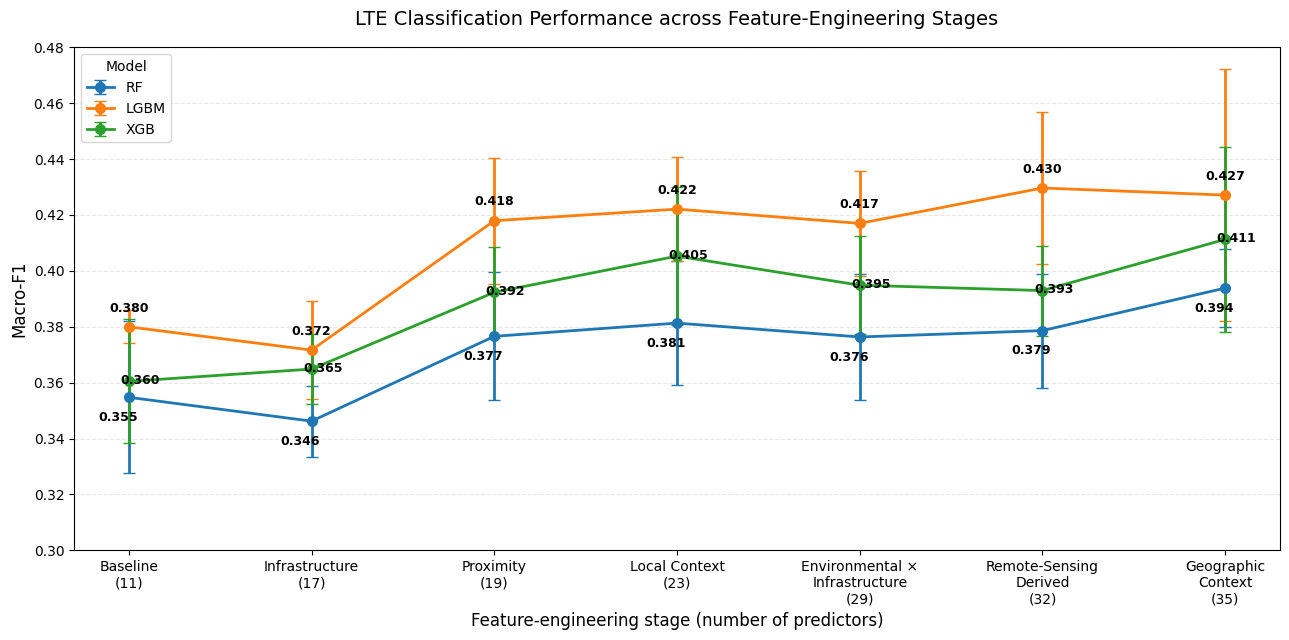

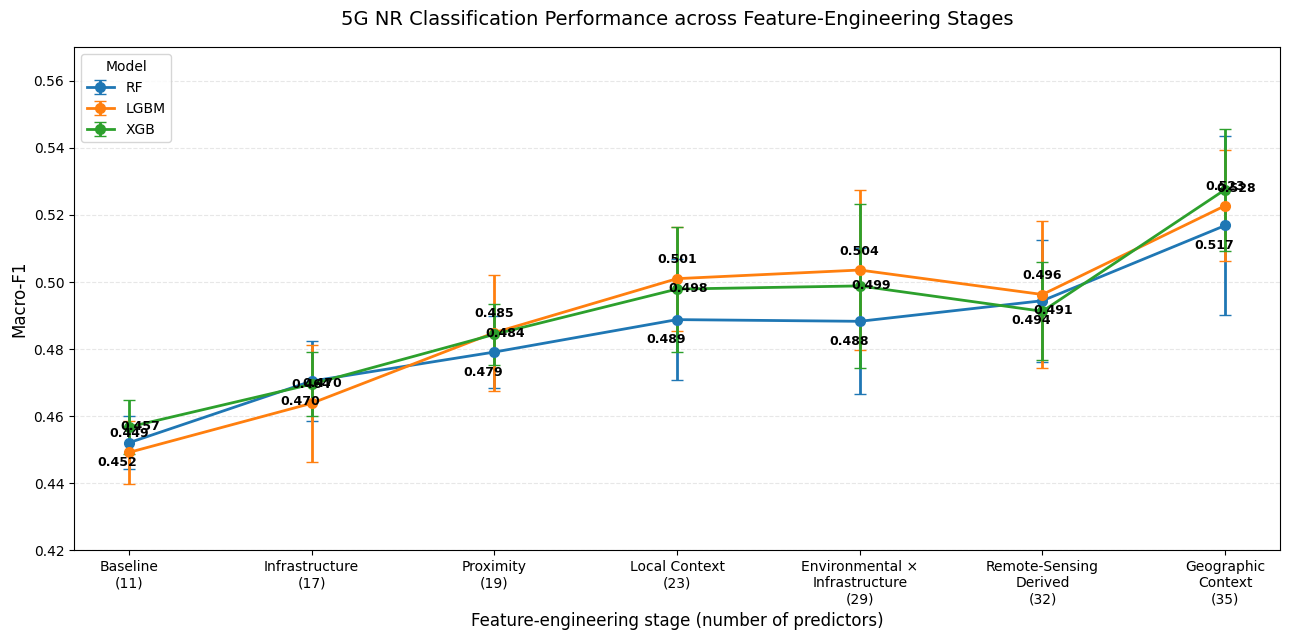

In [10]:
# ============================================================
# Cells 8–9. Macro-F1 across Feature-Engineering Stages
# ============================================================

import matplotlib.pyplot as plt

dataset_order = [
    "Dataset19",
    "Dataset20",
    "Dataset21",
    "Dataset22",
    "Dataset23",
    "Dataset24",
    "Dataset25"
]

stage_labels = [
    "Baseline\n(11)",
    "Infrastructure\n(17)",
    "Proximity\n(19)",
    "Local Context\n(23)",
    "Environmental ×\nInfrastructure\n(29)",
    "Remote-Sensing\nDerived\n(32)",
    "Geographic\nContext\n(35)"
]

model_order = [
    "RF",
    "LGBM",
    "XGB"
]

# Offsets prevent value labels from overlapping
annotation_offsets = {
    "RF": (-8, -17),
    "LGBM": (0, 11),
    "XGB": (8, -2)
}


def plot_feature_engineering_performance(
    results,
    target_col,
    title,
    y_limits
):

    target_results = results[
        results["target"] == target_col
    ].copy()

    plt.figure(figsize=(13, 6.5))

    for model in model_order:

        temp = target_results[
            target_results["model"] == model
        ].copy()

        temp["dataset"] = pd.Categorical(
            temp["dataset"],
            categories=dataset_order,
            ordered=True
        )

        temp = temp.sort_values("dataset")

        x_values = np.arange(
            len(stage_labels)
        )

        y_values = temp[
            "macro_f1_mean"
        ].to_numpy()

        y_errors = temp[
            "macro_f1_std"
        ].to_numpy()

        plt.errorbar(
            x_values,
            y_values,
            yerr=y_errors,
            marker="o",
            markersize=7,
            linewidth=2,
            capsize=4,
            label=model
        )

        # Add Macro-F1 value to each point
        for x, y in zip(
            x_values,
            y_values
        ):
            plt.annotate(
                f"{y:.3f}",
                xy=(x, y),
                xytext=annotation_offsets[model],
                textcoords="offset points",
                ha="center",
                fontsize=9,
                fontweight="bold"
            )

    plt.xticks(
        range(len(stage_labels)),
        stage_labels,
        fontsize=10
    )

    plt.xlabel(
        "Feature-engineering stage (number of predictors)",
        fontsize=12
    )

    plt.ylabel(
        "Macro-F1",
        fontsize=12
    )

    plt.title(
        title,
        fontsize=14,
        pad=16
    )

    plt.ylim(*y_limits)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.legend(
        title="Model"
    )

    plt.tight_layout()
    plt.show()


# LTE figure
plot_feature_engineering_performance(
    results=comparison_results,
    target_col="lte_signal_class",
    title=(
        "LTE Classification Performance across "
        "Feature-Engineering Stages"
    ),
    y_limits=(0.30, 0.48)
)

# 5G NR figure
plot_feature_engineering_performance(
    results=comparison_results,
    target_col="nr_signal_class",
    title=(
        "5G NR Classification Performance across "
        "Feature-Engineering Stages"
    ),
    y_limits=(0.42, 0.57)
)

In [11]:
# ============================================================
# Cell 9. Best Model Summary by Dataset
# ============================================================

summary = []

for dataset_name in dataset_order:

    dataset_results = comparison_results[
        comparison_results["dataset"] == dataset_name
    ]

    lte_best = (
        dataset_results[
            dataset_results["target"]
            == "lte_signal_class"
        ]
        .sort_values(
            "macro_f1_mean",
            ascending=False
        )
        .iloc[0]
    )

    nr_best = (
        dataset_results[
            dataset_results["target"]
            == "nr_signal_class"
        ]
        .sort_values(
            "macro_f1_mean",
            ascending=False
        )
        .iloc[0]
    )

    summary.append({
        "Dataset": dataset_name,
        "Features": int(lte_best["n_features"]),
        "LTE Best Model": lte_best["model"],
        "LTE Macro-F1": lte_best["macro_f1_mean"],
        "LTE SD": lte_best["macro_f1_std"],
        "5G NR Best Model": nr_best["model"],
        "5G NR Macro-F1": nr_best["macro_f1_mean"],
        "5G NR SD": nr_best["macro_f1_std"]
    })

summary_df = pd.DataFrame(summary)

display(summary_df.round(4))

,Dataset,Features,LTE Best Model,LTE Macro-F1,LTE SD,5G NR Best Model,5G NR Macro-F1,5G NR SD
0,Dataset19,11,LGBM,0.3800,0.0060,XGB,0.4568,0.0080
1,Dataset20,17,LGBM,0.3716,0.0177,RF,0.4704,0.0118
2,Dataset21,19,LGBM,0.4179,0.0226,LGBM,0.4849,0.0173
3,Dataset22,23,LGBM,0.4221,0.0185,LGBM,0.5010,0.0155
4,Dataset23,29,LGBM,0.4170,0.0189,LGBM,0.5036,0.0237
5,Dataset24,32,LGBM,0.4296,0.0271,LGBM,0.4963,0.0221
6,Dataset25,35,LGBM,0.4271,0.0451,XGB,0.5276,0.0182


In [13]:
# Separate LTE and 5G NR results
lte_results = comparison_results[
    comparison_results["target"] == "lte_signal_class"
].copy()

nr_results = comparison_results[
    comparison_results["target"] == "nr_signal_class"
].copy()

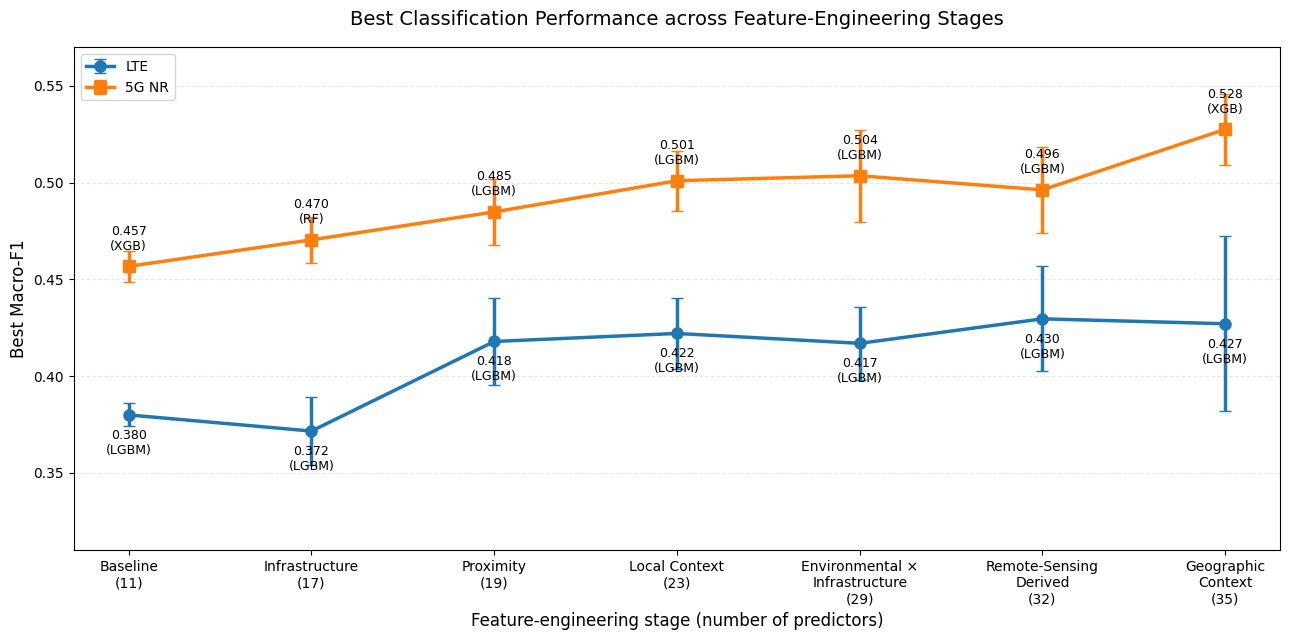

In [14]:
# ============================================================
# Cell 10. Best Macro-F1 across Feature-Engineering Stages
# ============================================================

stage_labels = [
    "Baseline\n(11)",
    "Infrastructure\n(17)",
    "Proximity\n(19)",
    "Local Context\n(23)",
    "Environmental ×\nInfrastructure\n(29)",
    "Remote-Sensing\nDerived\n(32)",
    "Geographic\nContext\n(35)"
]

# Extract the best model for each dataset and target
lte_best = (
    lte_results
    .loc[
        lte_results
        .groupby("dataset")["macro_f1_mean"]
        .idxmax()
    ]
    .copy()
)

nr_best = (
    nr_results
    .loc[
        nr_results
        .groupby("dataset")["macro_f1_mean"]
        .idxmax()
    ]
    .copy()
)

# Apply consistent dataset ordering
for best_results in [lte_best, nr_best]:

    best_results["dataset"] = pd.Categorical(
        best_results["dataset"],
        categories=dataset_order,
        ordered=True
    )

lte_best = (
    lte_best
    .sort_values("dataset")
    .reset_index(drop=True)
)

nr_best = (
    nr_best
    .sort_values("dataset")
    .reset_index(drop=True)
)

x_values = np.arange(
    len(stage_labels)
)

plt.figure(figsize=(13, 6.5))

# LTE
plt.errorbar(
    x_values,
    lte_best["macro_f1_mean"],
    yerr=lte_best["macro_f1_std"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    capsize=4,
    label="LTE"
)

# 5G NR
plt.errorbar(
    x_values,
    nr_best["macro_f1_mean"],
    yerr=nr_best["macro_f1_std"],
    marker="s",
    linewidth=2.5,
    markersize=8,
    capsize=4,
    label="5G NR"
)

# Add model names and Macro-F1 values
for x, (_, row) in enumerate(
    lte_best.iterrows()
):
    plt.annotate(
        f"{row['macro_f1_mean']:.3f}\n"
        f"({row['model']})",
        xy=(x, row["macro_f1_mean"]),
        xytext=(0, -28),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

for x, (_, row) in enumerate(
    nr_best.iterrows()
):
    plt.annotate(
        f"{row['macro_f1_mean']:.3f}\n"
        f"({row['model']})",
        xy=(x, row["macro_f1_mean"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.xticks(
    x_values,
    stage_labels,
    fontsize=10
)

plt.xlabel(
    "Feature-engineering stage (number of predictors)",
    fontsize=12
)

plt.ylabel(
    "Best Macro-F1",
    fontsize=12
)

plt.title(
    "Best Classification Performance across Feature-Engineering Stages",
    fontsize=14,
    pad=16
)

plt.ylim(0.31, 0.57)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()